## Week 1: Task EDA

In [24]:
# necessary liraries imported
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns


In [5]:
# loading datase
df = pd.read_csv("online_retail_II.csv")

In [9]:
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [15]:
print(f"Dataset Shape: ", {df.shape})

Dataset Shape:  {(1067371, 8)}


In [17]:
print(f"Dataset Columns and datatype: ", {df.info()})

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype  
---  ------       --------------    -----  
 0   Invoice      1067371 non-null  object 
 1   StockCode    1067371 non-null  object 
 2   Description  1062989 non-null  object 
 3   Quantity     1067371 non-null  int64  
 4   InvoiceDate  1067371 non-null  object 
 5   Price        1067371 non-null  float64
 6   Customer ID  824364 non-null   float64
 7   Country      1067371 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 65.1+ MB
Dataset Columns and datatype:  {None}


### Dataset Cleaning 

In [31]:
# counting the null values in the features
print(f"The columns with missing values are :", df.isnull().sum())

The columns with missing values are : Invoice             0
StockCode           0
Description      4382
Quantity            0
InvoiceDate         0
Price               0
Customer ID    243007
Country             0
dtype: int64


In [45]:
print("The percentage of missing values are" )
(df.isnull().sum()/len(df))*100

The percentage of missing values are


Invoice         0.000000
StockCode       0.000000
Description     0.410541
Quantity        0.000000
InvoiceDate     0.000000
Price           0.000000
Customer ID    22.766873
Country         0.000000
dtype: float64

In [46]:
df.duplicated().sum()

np.int64(34335)

### Revenue Column

In [47]:
df["Revenue"] = df["Quantity"] * df["Price"]

In [49]:
df["Revenue"]

0           83.40
1           81.00
2           81.00
3          100.80
4           30.00
            ...  
1067366     12.60
1067367     16.60
1067368     16.60
1067369     14.85
1067370     18.00
Name: Revenue, Length: 1067371, dtype: float64

### Plotting the top 10 products by revenue 

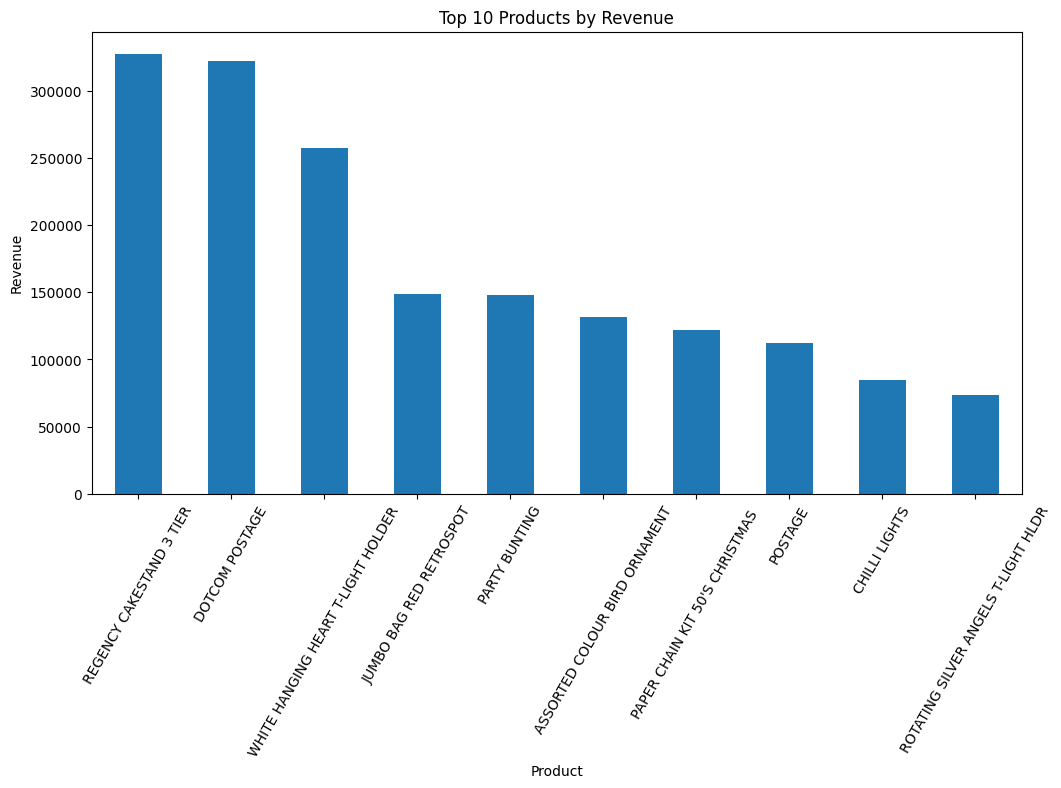

In [62]:
top_revenue = df.groupby("Description")["Revenue"].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(12,6))

top_revenue.plot(kind="bar")

plt.title("Top 10 Products by Revenue")

plt.xlabel("Product")

plt.ylabel("Revenue")

plt.xticks(rotation=60)

plt.show()

### Plotting the top 10 products by quantity 

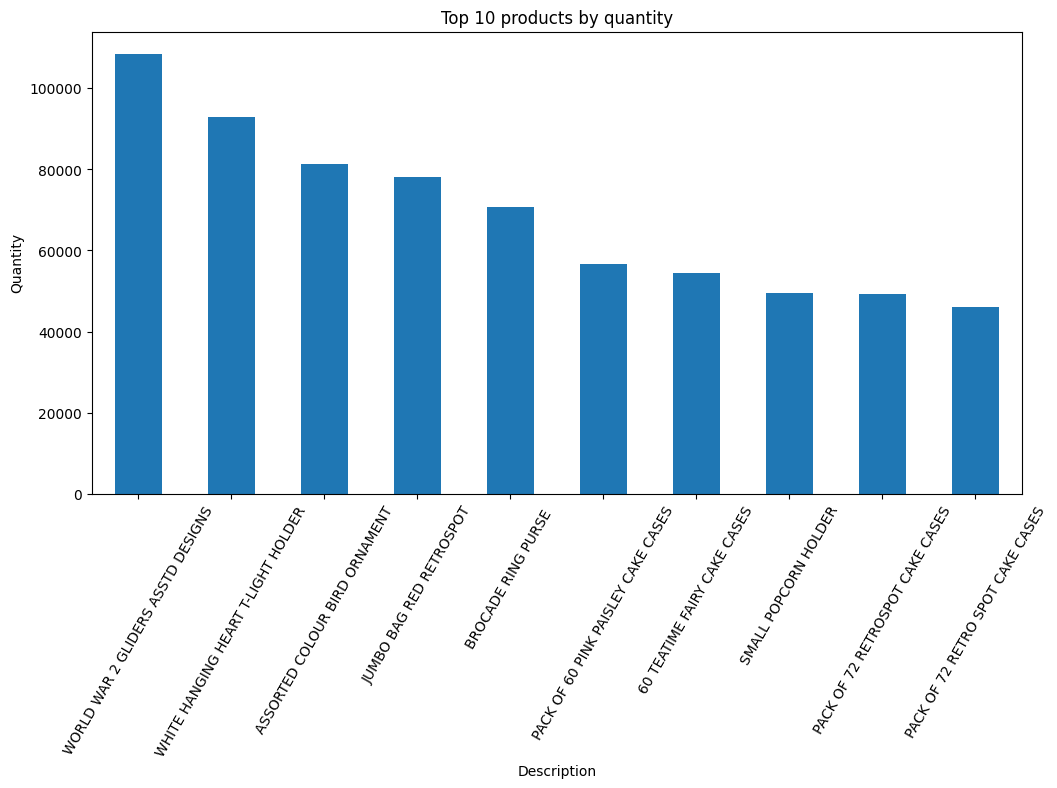

In [64]:
top_quantity= df.groupby("Description")["Quantity"].sum().sort_values(ascending=False).head(10)
plt.figure(figsize=(12,6))
top_quantity.plot(kind="bar")
plt.title("Top 10 products by quantity")

plt.xlabel("Description")
plt.ylabel("Quantity")
plt.xticks(rotation=60)

plt.show()

### Sales by Country

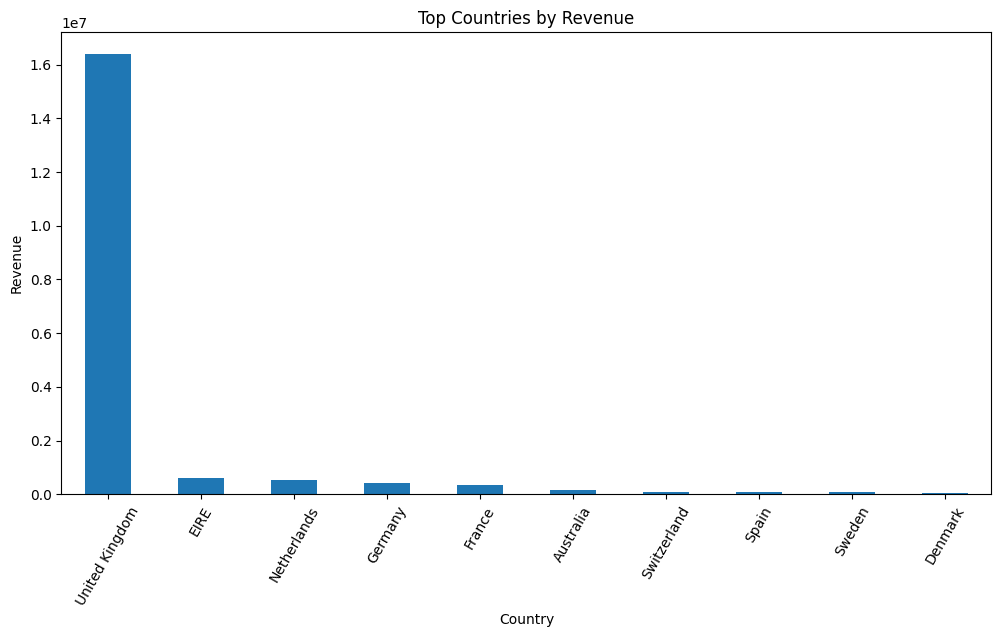

In [67]:
country_sales = df.groupby("Country")["Revenue"].sum().sort_values(ascending=False)

plt.figure(figsize=(12,6))

country_sales.head(10).plot(kind="bar")

plt.title("Top Countries by Revenue")

plt.xlabel("Country")

plt.ylabel("Revenue")
plt.xticks(rotation=60)

plt.show()

### Monthly Revenue Trend

In [68]:
# convert data
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

In [69]:
# create month
df["Month"] = df["InvoiceDate"].dt.to_period("M")

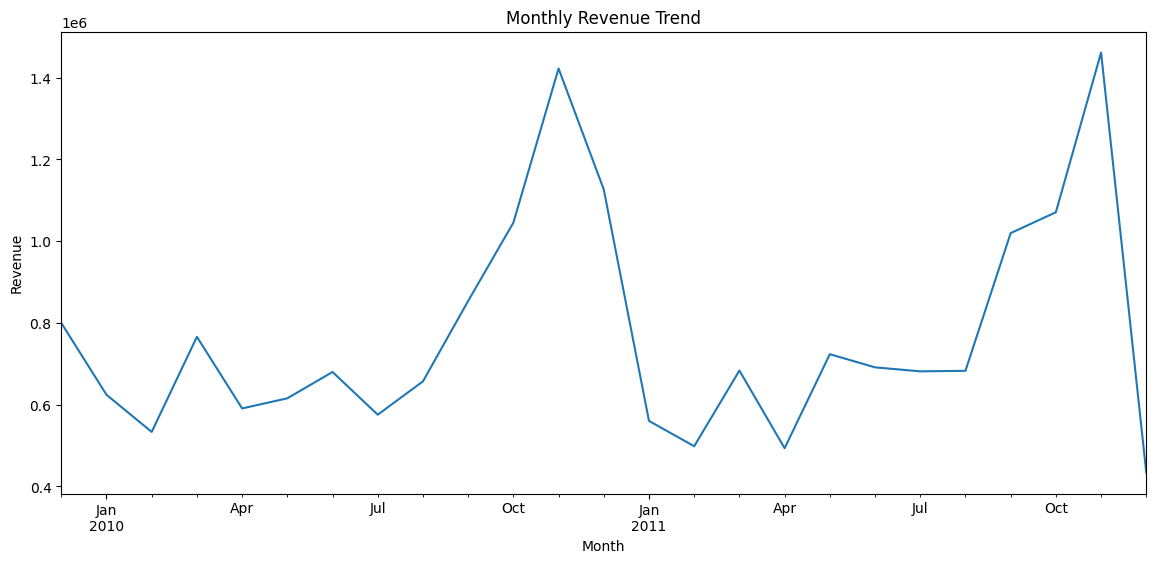

In [70]:
# Revenue
monthly = df.groupby("Month")["Revenue"].sum()

monthly.plot(figsize=(14,6))

plt.title("Monthly Revenue Trend")

plt.xlabel("Month")

plt.ylabel("Revenue")

plt.show()

### Correlation HeatMap

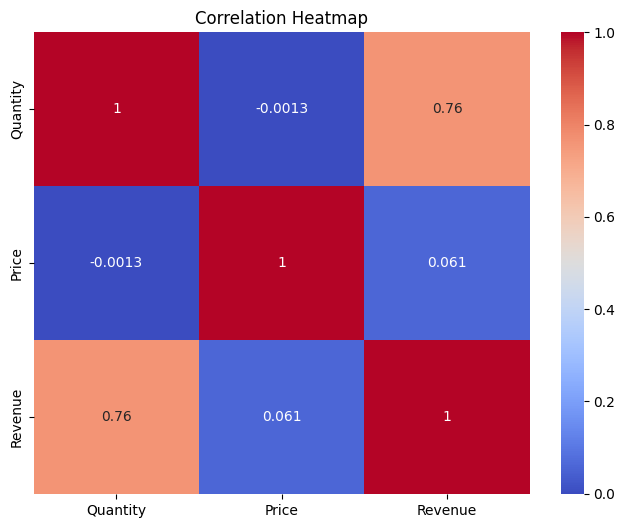

In [71]:
plt.figure(figsize=(8,6))

sns.heatmap(
    df[["Quantity","Price","Revenue"]].corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()

### Boxplot (outliers)

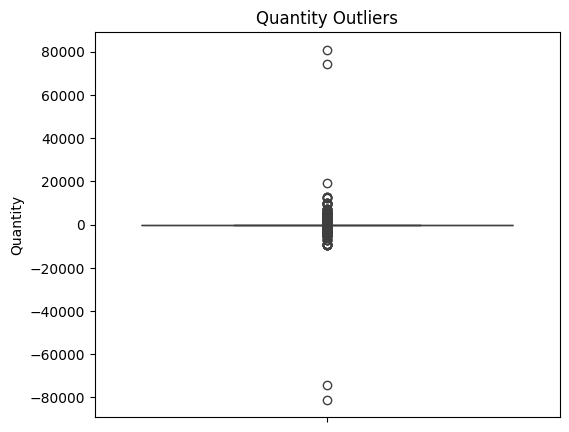

In [72]:
plt.figure(figsize=(6,5))

sns.boxplot(y=df["Quantity"])

plt.title("Quantity Outliers")

plt.show()

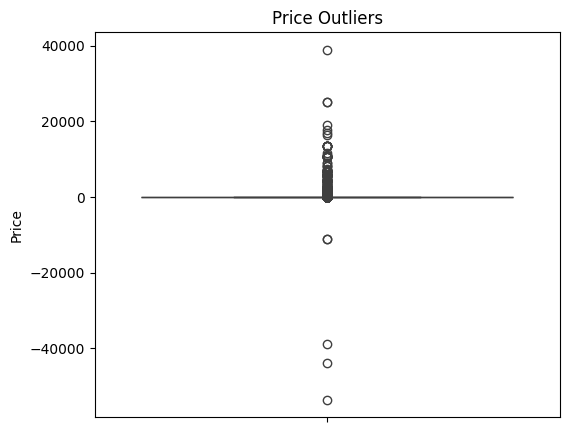

In [73]:
plt.figure(figsize=(6,5))

sns.boxplot(y=df["Price"])

plt.title("Price Outliers")

plt.show()

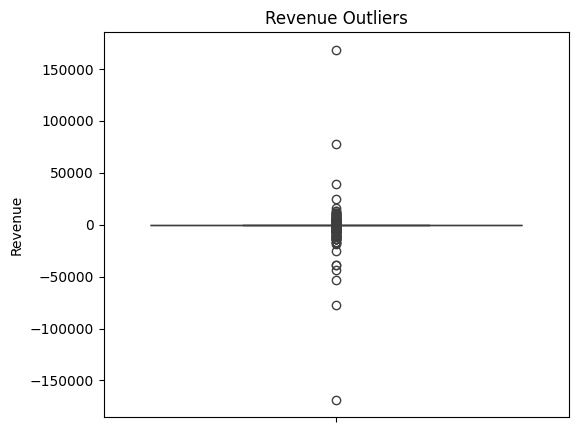

In [74]:
plt.figure(figsize=(6,5))

sns.boxplot(y=df["Revenue"])

plt.title("Revenue Outliers")

plt.show()